# AdaBoost Model for Plastic Hinge Length Prediction

The following is a Jupyter implementation of the plastic hinge length (PHL) prediction model developed for the study titled <i>Data-Driven Approach to Predict the Plastic Hinge Length of Reinforced Concrete Columns and Its Application</i> (Feng et al. 2020). For information on model development and validation, please refer to this article.

At the moment, <b>PHL predictions of the model are limited to reinforced concrete rectangular columns</b>. Studies to expand the model to different element shapes, types, and structural materials are underway.

In order to calculate the PHL for a column, fill out the fields above the <span style="background-color:#F0F0F0;padding:3px;"><small>Calculate PHL</small></span> button. Once all the fields are completed, press the <span style="background-color:#F0F0F0;padding:3px;"><small>Calculate PHL</small></span> button to compute PHL prediction of the model.

If desired, the load-displacement response of the column can be also computed. Fill out the fields after the line that shows the PHL prediction and press the <span style="background-color:#F0F0F0;padding:3px;"><small>Compute column response</small></span> button. You will see the column's <span style="background-color:#F0F0F0;padding:3px;"><small>Monotonic</small></span> or <span style="background-color:#F0F0F0;padding:3px;"><small>Cyclic</small></span> response curve, depending on your loading type selection for the PHL calculations.

For monotonic loading <a href="https://opensees.berkeley.edu/wiki/index.php/Concrete01_Material_--_Zero_Tensile_Strength">Concrete01</a> and for cyclic loading <a href="https://opensees.berkeley.edu/wiki/index.php/Concrete02_Material_--_Linear_Tension_Softening">Concrete02</a> material models in OpenSees are utilized. In both loading conditions, rebar behavior is simulated using the <a href="https://opensees.berkeley.edu/wiki/index.php/Steel02_Material_--_Giuffr%C3%A9-Menegotto-Pinto_Model_with_Isotropic_Strain_Hardening">Steel02</a> material.

In [14]:
# Load the required modules
import numpy as np
from math import pi, ceil
from os import path, remove
import subprocess
from responsePlot import respPlot
from pickle import load
import ipywidgets as widgets
from IPython.display import display
from IPython.display import HTML
from ipywidgets import Button, Layout
from IPython.display import Javascript

# Run all cells below
display(Javascript('IPython.notebook.execute_cells_below()'))

# Hide the raw code
HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
The raw code for this IPython notebook is hidden by default for improved user interaction.
To toggle on/off the raw code, click <a href="javascript:code_toggle()">here</a>. 
<br><br>In using the user interface, please hover your cursor over a variable name to view the variable's description.''')

<IPython.core.display.Javascript object>

In [15]:
# Specify the widgets for PHL calculation
loading_Toggle = widgets.ToggleButtons(
    options=['Monotonic', 'Cyclic'],
    description='Loading type:',
    description_tooltip='Loading type: Monotonic or Cyclic',
    disabled=False,
    button_style='',
    value='Cyclic'
)

style = {'description_width': '80px'}

B_tBox = widgets.FloatText(
    value=350.00,
    min=0,
    step=1,
    description='$B$ (mm):',
    description_tooltip='Column section width',
    disabled=False,
    style=style)
H_tBox = widgets.FloatText(
    value=250.00,
    min=0,
    step=1,
    description='$H$ (mm):',
    description_tooltip='Column section height',
    disabled=False,
    style=style)
L_tBox = widgets.FloatText(
    value=2010.00,
    min=0,
    step=1,
    description='$L$ (mm):',
    description_tooltip='Column height',
    disabled=False,
    style=style)
fc_tBox = widgets.FloatText(
    value=91.30,
    min=0,
    step=1,
    description='$f_c$ (MPa):',
    description_tooltip='Concrete compressive strength',
    disabled=False,
    style=style)
d_bBox = widgets.FloatText(
    value=20.00,
    min=0,
    step=1,
    description='$d_b$ (mm):',
    description_tooltip='Diameter of longitudinal reinforcement',
    disabled=False,
    style=style)
rhos_tBox = widgets.FloatText(
    value=2.74,
    min=0,
    step=0.01,
    description='$ρ_s$ (%):',
    description_tooltip='Longitudinal reinforcement ratio (Ratio of total longitudinal rebar area to B*H)',
    disabled=False,
    style=style)
fy_tBox = widgets.FloatText(
    value=521,
    min=0,
    step=1,
    description='$f_y$ (MPa):',
    description_tooltip='Yield strength of longitudinal reinforcement',
    disabled=False,
    style=style)
s_tBox = widgets.FloatText(
    value=70,
    min=0,
    step=1,
    description='$s$ (mm):',
    description_tooltip='Center-to-center spacing of transverse reinforcement',
    disabled=False,
    style=style)
rhov_tBox = widgets.FloatText(
    value=3.92,
    min=0,
    step=0.01,
    description='$ρ_ν$ (%):',
    description_tooltip='Transverse reinforcement ratio (Ratio of total transverse rebar area to B*H)',
    disabled=False,
    style=style)
fyv_tBox = widgets.FloatText(
    value=465,
    min=0,
    step=1,
    description='$f_{yν}$ (MPa):',
    description_tooltip='Yield strength of transverse reinforcement',
    disabled=False,
    style=style)
PoverP0_tBox = widgets.FloatText(
    value=0.31,
    min=0,
    step=0.01,
    description='$P$/$P_0$:',
    description_tooltip='Axial load ratio',
    disabled=False,
    style=style)
btnPHL = widgets.Button(
    description='Calculate PHL',
    layout=Layout(left='89px',width='210px'))

outputPHL = widgets.Output()

# Display the widgets
display(loading_Toggle, B_tBox, H_tBox, L_tBox, fc_tBox, d_bBox, rhos_tBox,
        fy_tBox, s_tBox, rhov_tBox, fyv_tBox, PoverP0_tBox, btnPHL)

# Once the Calculate PHL button is clicked, calculate the plastic hinge length
def btn_eventhandlerPHL(obj):
    outputPHL.clear_output()
    with outputPHL:
        # Get values of the widgets 
        loadingCat = loading_Toggle.value
        if loadingCat=='Monotonic':
            loading = 1
        elif  loadingCat=='Cyclic':
            loading = 2
        B = B_tBox.value
        H = H_tBox.value
        L = L_tBox.value
        fc = fc_tBox.value
        db = d_bBox.value
        rhos = rhos_tBox.value
        fy = fy_tBox.value
        s = s_tBox.value
        rhov = rhov_tBox.value
        fyv = fyv_tBox.value
        PoverP0 = PoverP0_tBox.value
        
        # Create the input vector
        X = np.array([loading,B,H,L,fc,db,rhos,fy,s,rhov,fyv,PoverP0])
        X = X.reshape(1, -1)

        # Load the data scaler
        scaler_filename = 'scaler.pkl'
        scaler = load(open(scaler_filename, 'rb'))
        
        # Normalize the data
        X = scaler.transform(X)

        # Load the AdaBoost model
        model_filename = 'AdaBoostPHL.pkl'
        model = load(open(model_filename, 'rb'))

        # Generate the model prediction
        yPredicted = model.predict(X)

        # Calculate the corresponding plastic hinge length
        PHL = yPredicted[0]*H
    
        # Print result
        print("Predicted Plastic Hinge Length =",round(PHL,2),"mm")

# Enable the event associated with the button click
btnPHL.on_click(btn_eventhandlerPHL)

ToggleButtons(description='Loading type:', description_tooltip='Loading type: Monotonic or Cyclic', index=1, o…

FloatText(value=350.0, description='$B$ (mm):', description_tooltip='Column section width', step=1.0, style=De…

FloatText(value=250.0, description='$H$ (mm):', description_tooltip='Column section height', step=1.0, style=D…

FloatText(value=2010.0, description='$L$ (mm):', description_tooltip='Column height', step=1.0, style=Descript…

FloatText(value=91.3, description='$f_c$ (MPa):', description_tooltip='Concrete compressive strength', step=1.…

...

FloatText(value=70.0, description='$s$ (mm):', description_tooltip='Center-to-center spacing of transverse rei…

FloatText(value=3.92, description='$ρ_ν$ (%):', description_tooltip='Transverse reinforcement ratio (Ratio of …

FloatText(value=465.0, description='$f_{yν}$ (MPa):', description_tooltip='Yield strength of transverse reinfo…

FloatText(value=0.31, description='$P$/$P_0$:', description_tooltip='Axial load ratio', step=0.01, style=Descr…

Button(description='Calculate PHL', layout=Layout(left='89px', width='210px'), style=ButtonStyle())

In [16]:
display(outputPHL)

Output()

FloatText(value=210.0, description='$E_s$ (GPa):', description_tooltip='Rebar initial elastic tangent modulus …

FloatText(value=0.02, description='$k$:', description_tooltip='Ratio between rebar post-yield tangent and init…

FloatText(value=30.0, description='$E_c$ (GPa):', description_tooltip='Concrete elastic modulus', step=1.0, st…

FloatText(value=90.0, description='$f_{pc}$ (MPa):', description_tooltip='Confined concrete compressive streng…

FloatText(value=0.003, description='$ε_{co}$:', description_tooltip='Concrete strain at confined concrete comp…

FloatText(value=60.0, description='$f_{pcu}$ (MPa):', description_tooltip='Confined concrete compressive stren…

FloatText(value=0.02, description='$ε_{cu}$:', description_tooltip='Concrete strain at crushing of confined co…

Button(description='Compute column response', layout=Layout(left='89px', width='210px'), style=ButtonStyle())

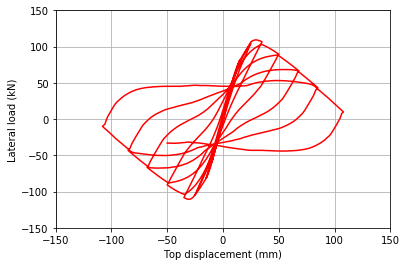

In [17]:
style = {'description_width': '80px'}

E_sBox = widgets.FloatText(
    value=210.00,
    min=0,
    step=1,
    description='$E_s$ (GPa):',
    description_tooltip='Rebar initial elastic tangent modulus ',
    disabled=False,
    style=style)
kBox = widgets.FloatText(
    value=0.02,
    min=0,
    step=0.001,
    description='$k$:',
    description_tooltip='Ratio between rebar post-yield tangent and initial elastic tangent moduli',
    disabled=False,
    style=style)
E_cBox = widgets.FloatText(
    value=30,
    min=0,
    step=1,
    description='$E_c$ (GPa):',
    description_tooltip='Concrete elastic modulus',
    disabled=False,
    style=style)
f_pcBox = widgets.FloatText(
    value=90.0,
    min=0,
    step=0.1,
    description='$f_{pc}$ (MPa):',
    description_tooltip='Confined concrete compressive strength',
    disabled=False,
    style=style)
eps_c0Box = widgets.FloatText(
    value=0.003,
    min=0,
    step=0.001,
    description='$ε_{co}$:',
    description_tooltip='Concrete strain at confined concrete compressive strength',
    disabled=False,
    style=style)
f_pcuBox = widgets.FloatText(
    value=60,
    min=0,
    step=0.1,
    description='$f_{pcu}$ (MPa):',
    description_tooltip='Confined concrete compressive strength at crushing',
    disabled=False,
    style=style)
eps_cuBox = widgets.FloatText(
    value=0.02,
    min=0,
    step=0.01,
    description='$ε_{cu}$:',
    description_tooltip='Concrete strain at crushing of confined concrete',
    disabled=False,
    style=style)

btnResponse = widgets.Button(
    description='Compute column response',
    layout=Layout(left='89px',width='210px'))

outputResponse = widgets.Output()

# Display the widgets
display(E_sBox,kBox,E_cBox,f_pcBox,eps_c0Box,f_pcuBox,eps_cuBox,btnResponse)

# Once the Calculate PHL button is clicked, calculate the plastic hinge length
def btn_eventhandlerResponse(obj):
    outputResponse.clear_output()
    with outputResponse:
        # File names for the column response input and output files
        inpFile = 'openSeesInp.tcl'
        outFile = 'NodeDisp.out'
        
        # Get values of the widgets 
        loadType = loading_Toggle.value.lower()
        B = B_tBox.value/1000
        H = H_tBox.value/1000
        L = L_tBox.value/1000
        db = d_bBox.value/1000
        nb = ceil(rhos_tBox.value*B*H/100/(pi*db**2/4))
        fy = fy_tBox.value*1000
        PHL = float((outputPHL.outputs[0]['text'].split())[-2])/1000
        dbv = db/2
        Es = E_sBox.value*1e6
        k = kBox.value
        Ecc = E_cBox.value*1e6
        fpc = -f_pcBox.value*1e3
        epsc0 = -eps_c0Box.value
        fpcu = -f_pcuBox.value*1e3
        epscu = -eps_cuBox.value
        
        # Define the list containing section and material properties
        parameters = [B, H, L, db, nb, fy, PHL, dbv, Es,
              k, Ecc, fpc, epsc0, fpcu, epscu]

        # Create the OpenSees Input
        templateFile = path.join('OpenSees',f"{loadType}Template.tcl")

        f1 = open(templateFile,'r')
        f2 = open(inpFile,'w')
        line = f1.readline()
        nLine = 1
        while line:
            if nLine in range(14,29):
                parsedStr = line.split()
                line = line.replace(parsedStr[2],f"{parameters[nLine-14]};")        
            f2.write(line)
            line = f1.readline()
            nLine += 1
        f1.close(); f2.close()

        # Run OpenSees
        subprocess.run(["OpenSees","openSeesInp.tcl"])

        # Read the column response
        respData = np.genfromtxt(outFile)
        disp = respData[:,1]*1000
        load = respData[:,0]

        # Cleanup the response data
        if loadType =='monotonic':
            disp = np.append(0, disp)
            load = np.append(0, load)

        # Plot column response
        respPlot(disp,load,loadType)

        # Remove OpenSees input and output files saved in the local directory
        remove(inpFile)
        remove(outFile)

# Enable the event associated with the button click
btnResponse.on_click(btn_eventhandlerResponse)